# Impact of $A$ on a simple dipole map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when no other effect but the monopole is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Reading data

In [3]:
DIR = "Fit_Dipole/Dipole_Monopole/Dipole_Monopole_"
sufix = "Param_study_Monop_poissVar"
file = DIR + sufix +".fits"

data2 = fitsio.FITS(file)
data2


  file: Fit_Dipole/Dipole_Monopole/Dipole_Monopole_Param_study_Monop_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS
  2      BINARY_TBL      A_STUDY

In [4]:
dfMinuit_filtered = Table(data2['A_STUDY'].read())
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64
01KT6XEKH4B04YSZD27Y83981X,999990.4910346629,1000000.0,4.510527531267144,False,0.0,inf,0.00101455356799416,1.0,7.812511381370462e-06,False,0.0,1.0,168.01702927350772,100.0,0.4448069461611084,False,0.0,360.0,-7.303158972892995,0.0,0.4412061137299972,False,-90.0,90.0,True,1000000,0.001,168,-7
01KT6XEPF842R50YYVCC49Q35K,999997.3349211538,1000000.0,4.510542971780524,False,0.0,inf,0.0010995814173989551,1.0,7.81246554068082e-06,False,0.0,1.0,167.4762611512317,100.0,0.40959340572128156,False,0.0,360.0,-6.346394479170673,0.0,0.40709141255131653,False,-90.0,90.0,True,1000000,0.0010985411419875584,168,-7
01KT6XESAJJZVH3Y9PY3WJD9EE,999990.0626512828,1000000.0,4.5105265356833115,False,0.0,inf,0.0011944607431000575,1.0,7.812426244789626e-06,False,0.0,1.0,168.32074533205366,100.0,0.3772456348678759,False,0.0,360.0,-6.585378922145879,0.0,0.3747598268848451,False,-90.0,90.0,True,1000000,0.0012067926406393288,168,-7
01KT6XEWCHVZ9ABZRZV859PSVR,1000008.7071618654,1000000.0,4.51056863903068,False,0.0,inf,0.001329880290833447,1.0,7.812341241547876e-06,False,0.0,1.0,167.7534414115416,100.0,0.33868509673624203,False,0.0,360.0,-6.370213654155522,0.0,0.33659928973267794,False,-90.0,90.0,True,1000000,0.0013257113655901094,168,-7
01KT6XEZQ860XQ3E6SG8PJ7RWD,999997.8910711217,1000000.0,4.510544215445407,False,0.0,inf,0.0014564707321150982,1.0,7.812446636236946e-06,False,0.0,1.0,167.9151242549609,100.0,0.3096133631714224,False,0.0,360.0,-6.956117564159641,0.0,0.307339235849732,False,-90.0,90.0,True,1000000,0.0014563484775012444,168,-7
01KT6XF2FZ1Z64X5WXBR9RKTK8,1000003.8608266163,1000000.0,4.510557688423432,False,0.0,inf,0.0015835028424455776,1.0,7.812466757065018e-06,False,0.0,1.0,168.32072095733727,100.0,0.2846459130388155,False,0.0,360.0,-6.742617969214664,0.0,0.2826799979653889,False,-90.0,90.0,True,1000000,0.0015998587196060573,168,-7
01KT6XF57GX1BT9PYEREKSGWEJ,1000001.7296307678,1000000.0,4.510552883381024,False,0.0,inf,0.0017549907665734266,1.0,7.812452023248312e-06,False,0.0,1.0,167.98853150141161,100.0,0.2567773104528186,False,0.0,360.0,-6.639935989111901,0.0,0.25506009026503396,False,-90.0,90.0,True,1000000,0.0017575106248547913,168,-7
01KT6XF7W4NN0A0PPHK2PPFZ7F,1000001.334466953,1000000.0,4.510551985586062,False,0.0,inf,0.0019245104612216261,1.0,7.812407783692934e-06,False,0.0,1.0,168.10168336690836,100.0,0.2343921981855317,False,0.0,360.0,-7.109086345625401,0.0,0.2325930416250297,False,-90.0,90.0,True,1000000,0.0019306977288832496,168,-7
01KT6XFAJA0JB39C8PYZKBC3WZ,999997.1272900378,1000000.0,4.510542497970164,False,0.0,inf,0.0021175775788449354,1.0,7.812436068515985e-06,False,0.0,1.0,167.82764417101436,100.0,0.21279365481328227,False,0.0,360.0,-6.596422766869494,0.0,0.21138608237827672,False,-90.0,90.0,True,1000000,0.0021209508879201904,168,-7


#### Plotting graphs

Saving Dip_A_study_val_PoissVar in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_val_PoissVar.pdf


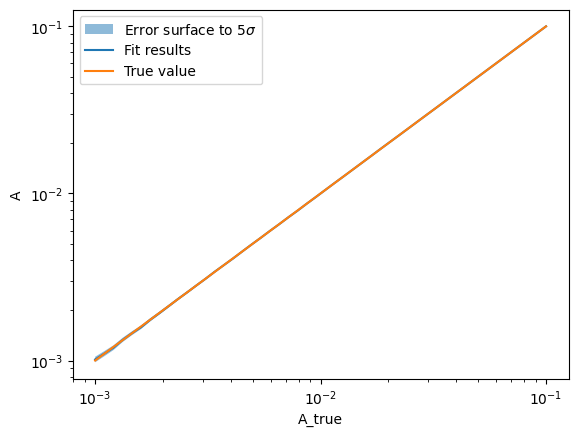

In [5]:
compareFit_val(dfMinuit_filtered, "A", "A", yscale='log', nsigma=5)
output_path = "Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/"
poissSuffix = "_PoissVar"
suffix = "Dip_A_study_val"
get_savefig(plt, output_path, suffix + poissSuffix)

Saving Dip_A_study_err_PoissVar in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_err_PoissVar.pdf


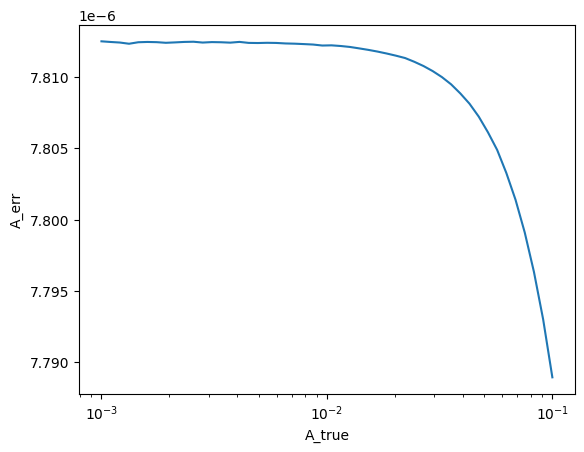

In [6]:
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_err"], label="Fit error")
plt.xlabel('A_true')
plt.ylabel('A_err')
plt.xscale('log');

sufix = "Dip_A_study_err"
get_savefig(plt, output_path, sufix + poissSuffix)

Saving Dip_A_study_diffARaDec_PoissVar in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_diffARaDec_PoissVar.pdf


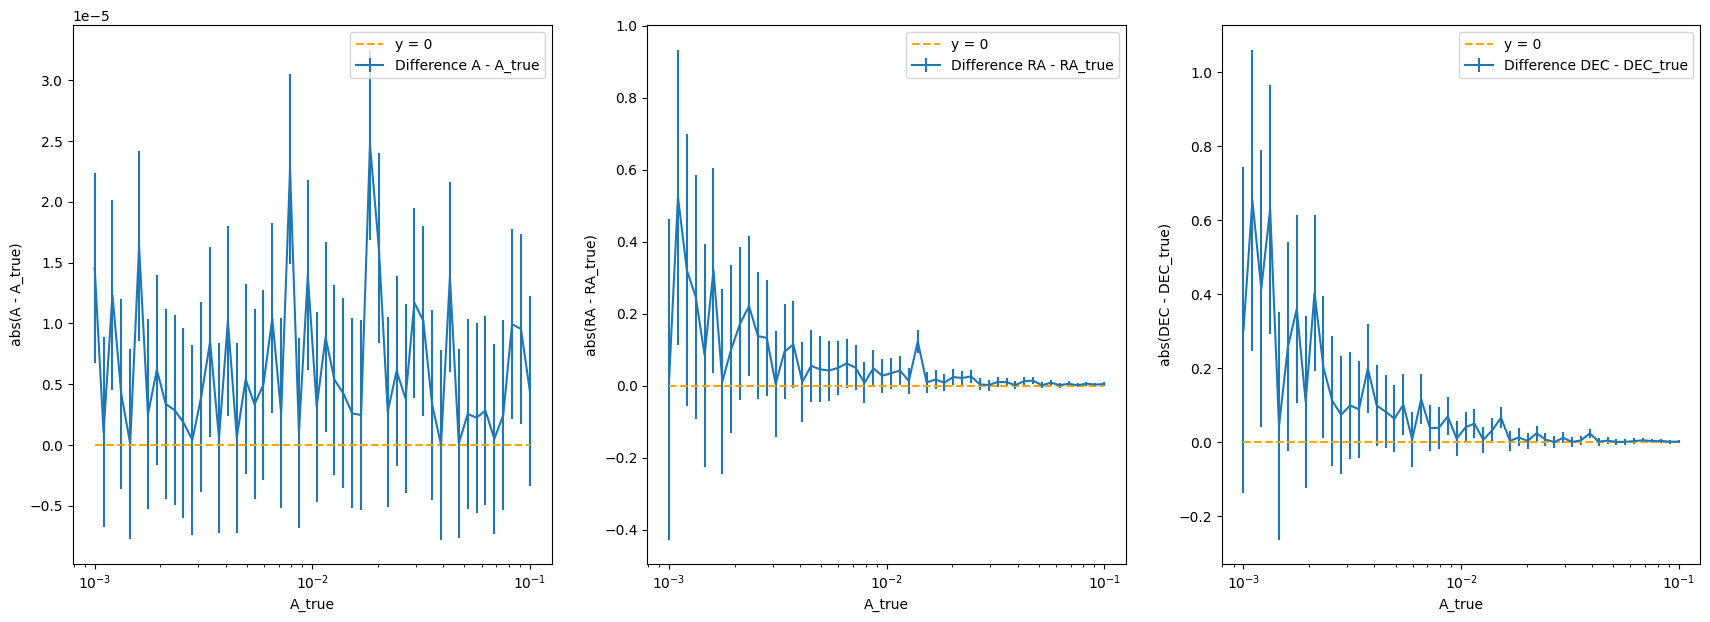

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1, figax=(fig, ax[1]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1, figax=(fig, ax[2]), surface=False)

sufix = "Dip_A_study_diffARaDec"
get_savefig(plt, output_path, sufix + poissSuffix)

Saving Dip_A_study_ratioARaDec_PoissVar in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_ratioARaDec_PoissVar.pdf


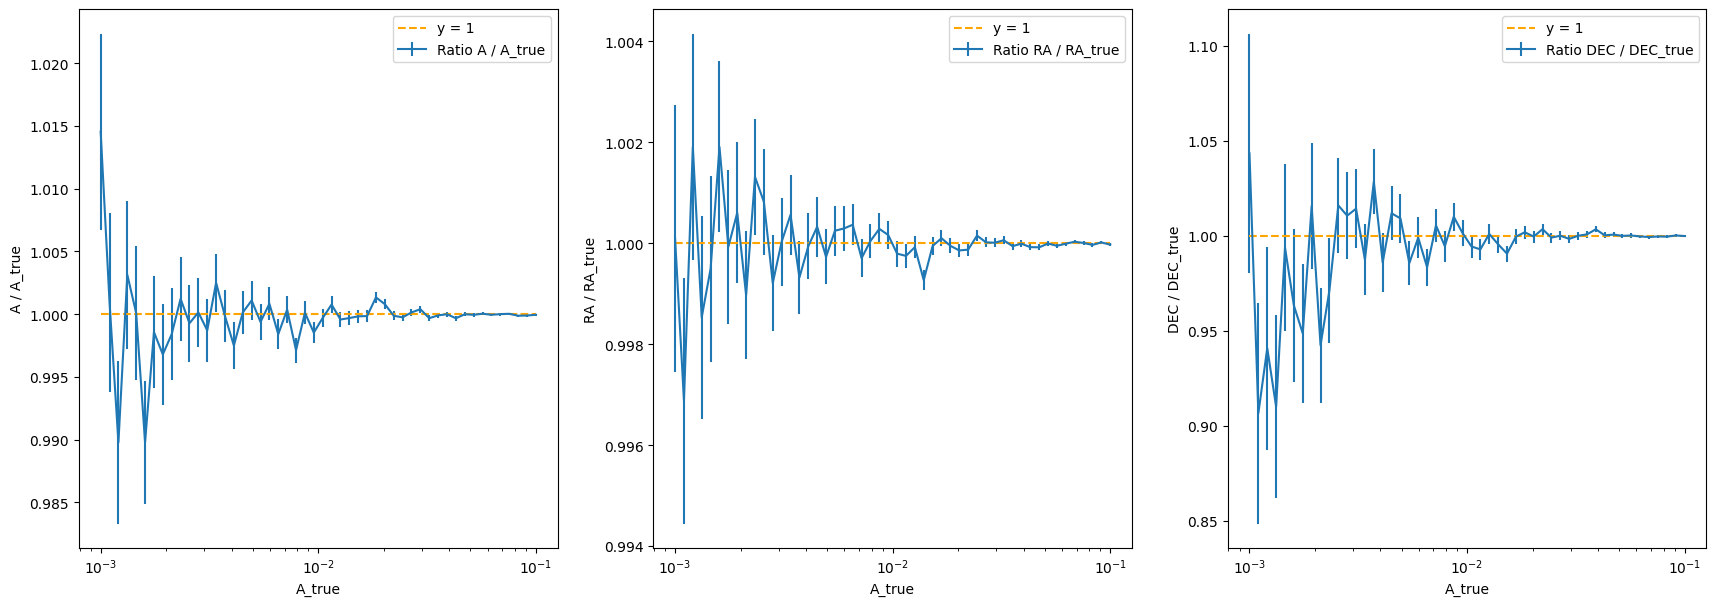

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1, figax=(fig, ax[2]), surface=False)

sufix = "Dip_A_study_ratioARaDec"
get_savefig(plt, output_path, sufix + poissSuffix)

Saving Dip_A_study_valARaDec_PoissVar in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_valARaDec_PoissVar.pdf


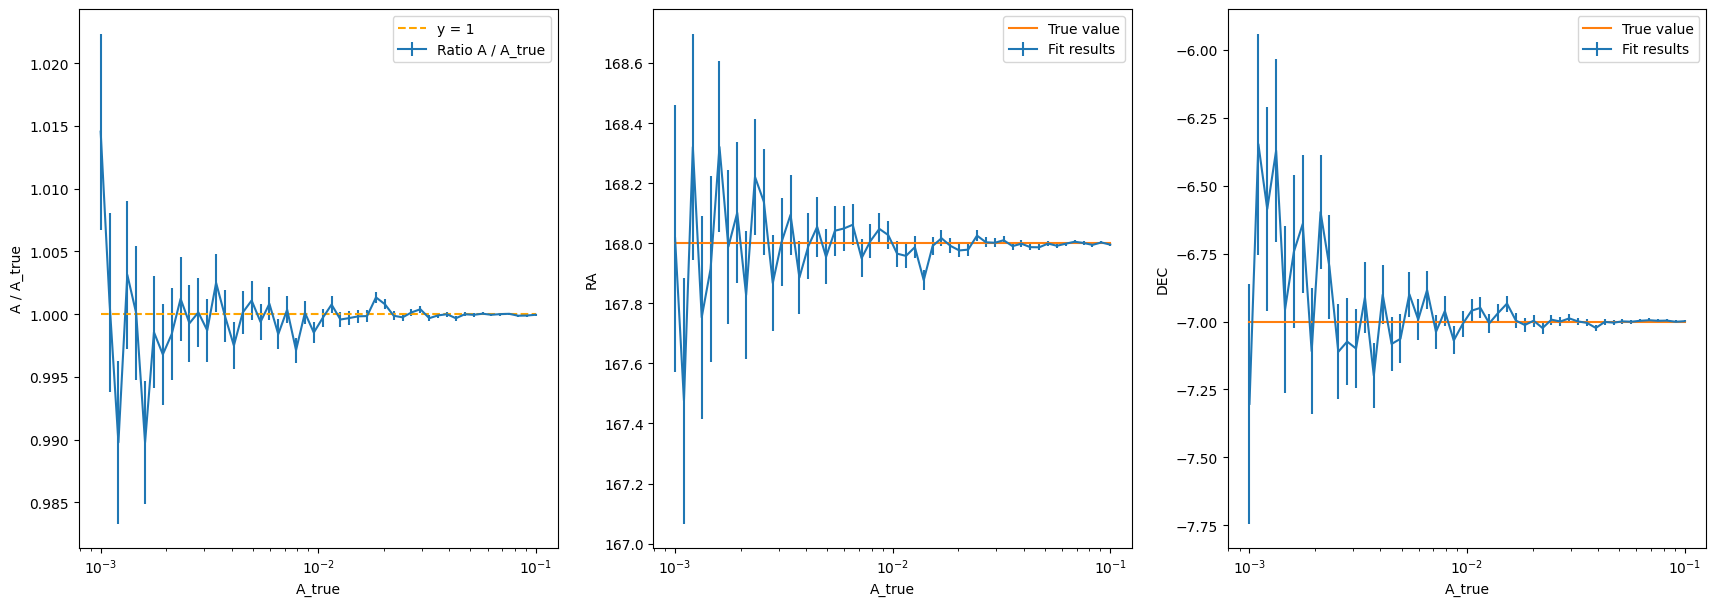

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=1, figax=(fig, ax[1]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=1, figax=(fig, ax[2]), surface=False)

sufix = "Dip_A_study_valARaDec"
get_savefig(plt, output_path, sufix + poissSuffix)

Saving Dip_A_study_valARaDec_PoissVar in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_valARaDec_PoissVar.pdf


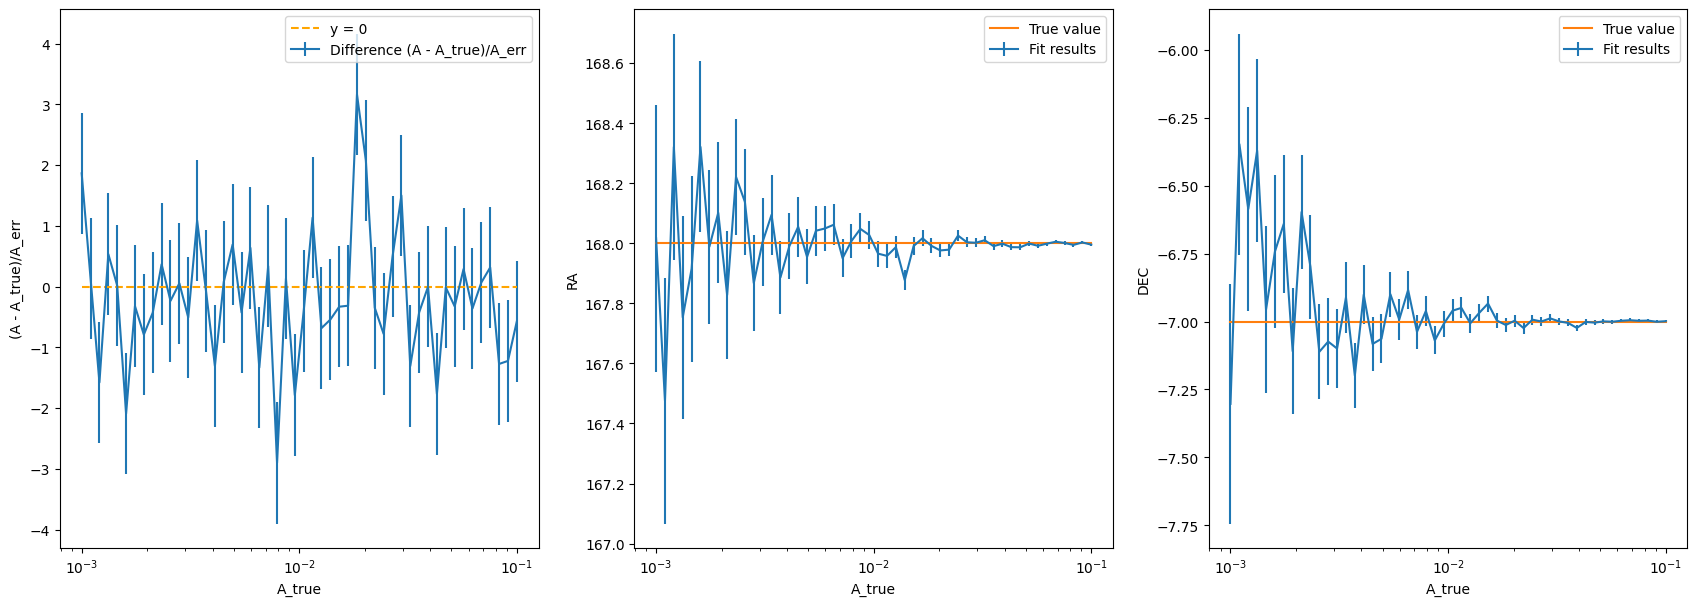

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diffRatio(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=1, figax=(fig, ax[1]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=1, figax=(fig, ax[2]), surface=False)

sufix = "Dip_A_study_valARaDec"
get_savefig(plt, output_path, sufix + poissSuffix)